In [8]:
from sklearn import datasets
import numpy as np

breast_cancer = datasets.load_breast_cancer()
feature_matrix = breast_cancer.data
target_labels = breast_cancer.target

print(feature_matrix.shape)
print(target_labels.shape)

number_of_samples = np.bincount(target_labels)
print(number_of_samples)

# Data set is mildly imbalanced, with 357 benign and 212 malignant.
# If one class is more frequent, a classifier may achieve high accuracy by most predicting
# the majority class, while doing poorly on the minority 

(569, 30)
(569,)
[212 357]


In [22]:
# Question 2 

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets
from sklearn.metrics import accuracy_score
breast_cancer = datasets.load_breast_cancer()
feature_matrix = breast_cancer.data
target_labels = breast_cancer.target

features_train, features_test, target_labels_train, target_labels_test = train_test_split(
    feature_matrix, target_labels, 
    test_size=0.20, random_state=42, 
    stratify=target_labels)

decision_tree_classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)
decision_tree_classifier.fit(features_train, target_labels_train)

train_pred = decision_tree_classifier.predict(features_train)
print(f"Train accuracy: {accuracy_score(target_labels_train, train_pred):.4f}")

test_pred = decision_tree_classifier.predict(features_test)
print(f"Test accuracy: {accuracy_score(target_labels_test, test_pred):.4f}")


# Entropy measures class impurity at a node: H(S) = −p1 log2(p1) − · · · − pn log2(pn).
# H=0 (pure), H=1 (max entropy).
# The observed results suggest clear overfitting as the tree memorized the
# training data and generalizes poorly. 

Train accuracy: 1.0000
Test accuracy: 0.9123


In [32]:
# Question 3

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets
from sklearn.metrics import accuracy_score

features_train, features_test, target_labels_train, target_labels_test = train_test_split(
    feature_matrix, target_labels, 
    test_size=0.33, random_state=42,
    stratify=target_labels)

constrained_dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=42)

constrained_dt.fit(features_train, target_labels_train)

train_accuracy = constrained_dt.score(features_train, target_labels_train)
test_accuracy = constrained_dt.score(features_test, target_labels_test)

print(f"Train accuracy: {train_accuracy:.4f}, Test accuracy: {test_accuracy:.4f}")

feature_names = breast_cancer.feature_names
importances = constrained_dt.feature_importances_

top5_indices = np.argsort(importances)[::-1][:5]

print("Top 5 most important features:")
for i in range(5):
    idx = top5_indices[i]
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

# Controlling complexity reduces overfitting by preventing excessive splits.
# Feature importance is the total impurity reduction from splits on the feature.

Train accuracy: 0.9816, Test accuracy: 0.8989
Top 5 most important features:
1. worst radius: 0.7656
2. worst concave points: 0.1329
3. worst texture: 0.0386
4. texture error: 0.0224
5. worst concavity: 0.0206


In [20]:
# Question 4

from sklearn import datasets
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
import numpy as np

breast_cancer = datasets.load_breast_cancer()
feature_matrix = breast_cancer.data
target_labels = breast_cancer.target

features_train, features_test, target_labels_train, target_labels_test = train_test_split(feature_matrix, target_labels, 
                                                                                          test_size=0.20, random_state=42,
                                                                                         stratify=target_labels)

scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

breast_cancer_classifier_model = Sequential([
    Dense(16, activation='relu', input_shape=(30,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

breast_cancer_classifier_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
breast_cancer_classifier_model.fit(
    features_train_scaled, target_labels_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

train_loss, train_accuracy = breast_cancer_classifier_model.evaluate(features_train_scaled, 
                                          target_labels_train,
                                          verbose=0)
test_loss, test_accuracy = breast_cancer_classifier_model.evaluate(features_test_scaled, 
                                          target_labels_test,
                                          verbose=0)

print(f"Train accuracy: {train_accuracy:.4f}, Test accuracy: {test_accuracy:.4f}")

# Feature scaling is necessary for neural networks because it prevents feature dominance,
# and keeps activations in a useful range.
# The epochs argument specifies how many times the model passes through the etire
# training dataset during training

Epoch 1/50


C:\Users\Fowls\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3764 - loss: 0.6878 - val_accuracy: 0.4615 - val_loss: 0.6412
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5632 - loss: 0.6092 - val_accuracy: 0.6044 - val_loss: 0.5764
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6978 - loss: 0.5576 - val_accuracy: 0.7033 - val_loss: 0.5298
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7802 - loss: 0.5110 - val_accuracy: 0.7912 - val_loss: 0.4824
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8599 - loss: 0.4582 - val_accuracy: 0.8352 - val_loss: 0.4301
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8874 - loss: 0.3983 - val_accuracy: 0.8901 - val_loss: 0.3765
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9176 - loss: 0.3434 - val_accuracy: 0.9121 - val_loss: 0.3294
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9313 - loss: 0.3000 - val_accuracy: 0.9121 - val_loss: 0.2897
Ep

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


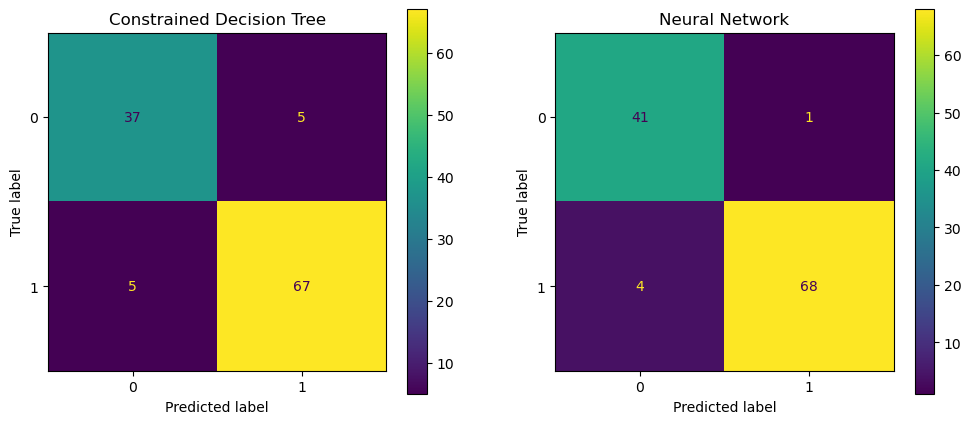

In [36]:
# Question 5
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

features_train, features_test, target_labels_train, target_labels_test = train_test_split(feature_matrix, target_labels, 
                                                                                          test_size=0.20, random_state=42,
                                                                                         stratify=target_labels)

tree_predictions = constrained_dt.predict(features_test)

nn_pred_prob = breast_cancer_classifier_model.predict(features_test_scaled)
nn_predictions = (nn_pred_prob > 0.5).astype(int).flatten()

fig, axes = plt.subplots(1,2, figsize=(12,5))

cm_tree = confusion_matrix(target_labels_test, tree_predictions)
ConfusionMatrixDisplay(cm_tree).plot(ax=axes[0])
axes[0].set_title('Constrained Decision Tree')

cm_nn = confusion_matrix(target_labels_test, nn_predictions)
ConfusionMatrixDisplay(cm_nn).plot(ax=axes[1])
axes[1].set_title('Neural Network')

plt.show()


# Prefer Neural Network for breast cancer diagnosis
# Tree advantage: Highly interpretable. 
# Tree limitation: Prone to overfitting without careful tuning.
# NN advantage: Slightly higher accuracy
# NN limitation: Black blox which makes it hard to explain individual predictions to doctors.

In [37]:
# Question 6
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

x_train = x_train[..., None]
x_test = x_test[..., None]

print("train shape", x_train.shape)
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Flatten()
])

model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10, activation="softmax"))

model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"] )
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=15, batch_size=64)


test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("test loss:", test_loss)
print("test acc:", test_acc)

probs = model.predict(x_test[:1], verbose=0)[0]
pred = int(tf.argmax(probs))

print("true:", int(y_test[0]))
print("pred:", pred)

# CNNs are preferred over fully connected nets for images because of hierarchical features, 
# and parameter sharing.
# Convolution layers learn hierarchical filters.

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
train shape (60000, 28, 28, 1)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 128)                 │         200,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 206,922 (808.29 KB)

 Trainable params: 206,922 (808.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8097 - loss: 0.5330 - val_accuracy: 0.8690 - val_loss: 0.3565
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8767 - loss: 0.3430 - val_accuracy: 0.8883 - val_loss: 0.2965
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8937 - loss: 0.2931 - val_accuracy: 0.8955 - val_loss: 0.2766
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9026 - loss: 0.2654 - val_accuracy: 0.9020 - val_loss: 0.2588
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9099 - loss: 0.2434 - val_accuracy: 0.9085 - val_loss: 0.2465
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9171 - loss: 0.2231 - val_accuracy: 0.9150 - val_loss: 0.2324
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9228 - loss: 0.2068 - val_accuracy: 0.9133 - val_loss: 0.2270
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9280 - loss: 0.1952 - val_accuracy: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


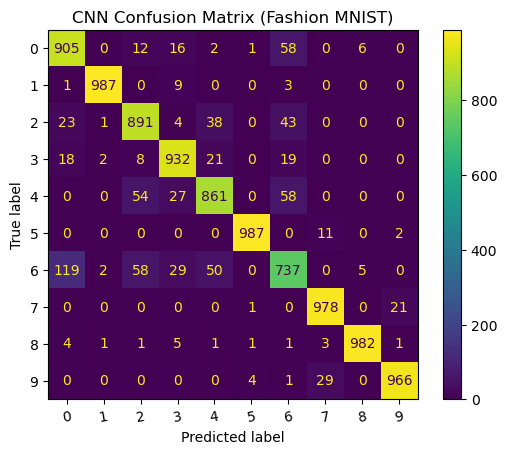

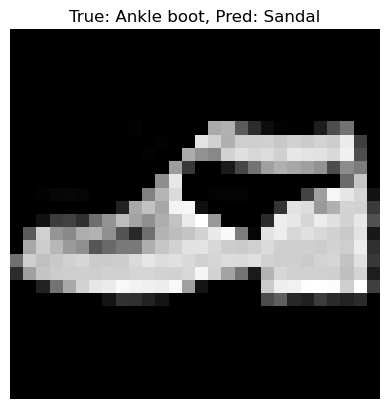

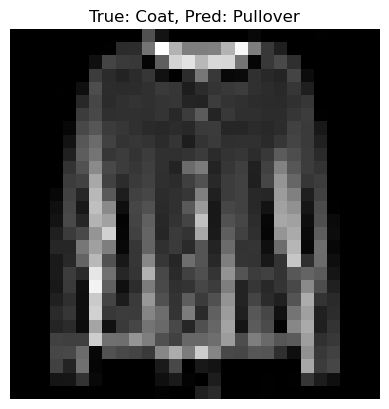

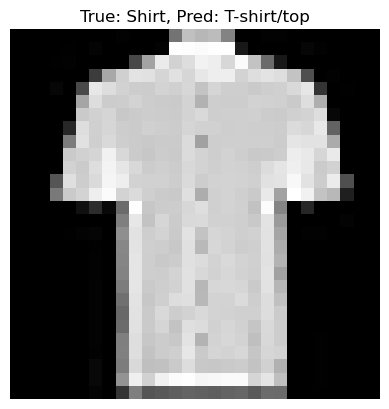

In [45]:
# Question 7
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(xticks_rotation=10)
plt.title("CNN Confusion Matrix (Fashion MNIST)")
plt.show()

misclassified_idx = np.where(y_pred != y_test)[0]

sample_idx = misclassified_idx[:3]

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
              ]

for i in sample_idx:
    plt.figure()
    plt.imshow(x_test[i].squeeze(),  cmap="gray")
    plt.title(f"True: {class_names[y_test[i]]}, Pred: {class_names[y_pred[i]]}")
    plt.axis("off")
    plt.show()

# One pattern in the misclassifications is that the model confuses items with 
# similar silhouettes and textures.
# A realistic way to improve CNN performance is to use a slightly deeper CNN to
# learn more robust, invariant features.